In [ ]:
import wandb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
api = wandb.Api()

sns.set_theme(style="whitegrid")

wandb: [wandb.Api()] Loaded credentials for https://api.wandb.ai from /home/redhound/.netrc.


#### Get runs

In [2]:
runs_cpu_standard = api.runs("mayur1009/ytm-benchmark", filters = {"group": "mnist", "config.device": "cpu", "config.approach": "standard"})
runs_cpu_discrete = api.runs("mayur1009/ytm-benchmark", filters = {"group": "mnist", "config.device": "cpu", "config.approach": "discrete"})
runs_cuda_standard = api.runs("mayur1009/ytm-benchmark", filters = {"group": "mnist", "config.device": "cuda", "config.approach": "standard"})
runs_cuda_discrete = api.runs("mayur1009/ytm-benchmark", filters = {"group": "mnist", "config.device": "cuda", "config.approach": "discrete"})

df_cpu_standard = runs_cpu_standard.histories(x_axis="epoch", format="pandas")
df_cpu_discrete = runs_cpu_discrete.histories(x_axis="epoch", format="pandas")
df_cuda_standard = runs_cuda_standard.histories(x_axis="epoch", format="pandas")
df_cuda_discrete = runs_cuda_discrete.histories(x_axis="epoch", format="pandas")

## Accuracy comparison.

Text(0.5, 0.98, 'Test Accuracy')

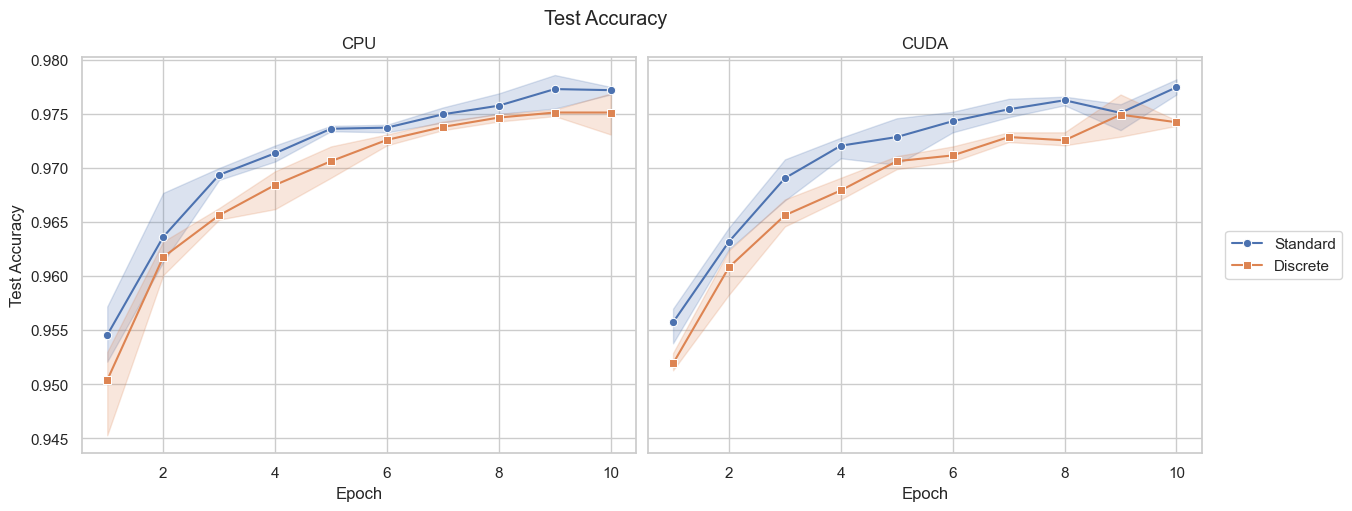

In [3]:
fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(12, 5), sharey=True, layout="compressed")

sns.lineplot(data=df_cpu_standard, x="epoch", y="test_acc", ax=ax0, label="Standard", marker="o")
sns.lineplot(data=df_cpu_discrete, x="epoch", y="test_acc", ax=ax0, label="Discrete", marker="s")
ax0.set_title("CPU")
ax0.set_ylabel("Test Accuracy")
ax0.set_xlabel("Epoch")
ax0.get_legend().remove()

sns.lineplot(data=df_cuda_standard, x="epoch", y="test_acc", ax=ax1, label="Standard", marker="o")
sns.lineplot(data=df_cuda_discrete, x="epoch", y="test_acc", ax=ax1, label="Discrete", marker="s")
ax1.set_title("CUDA")
ax1.set_ylabel("Test Accuracy")
ax1.set_xlabel("Epoch")
ax1.get_legend().remove()

handles, labels = ax0.get_legend_handles_labels()
fig.legend(handles, labels, bbox_to_anchor=(1.01, 0.5), loc="center left")
fig.suptitle("Test Accuracy")

## Fit Time

Text(0.5, 0.98, 'Fit Time')

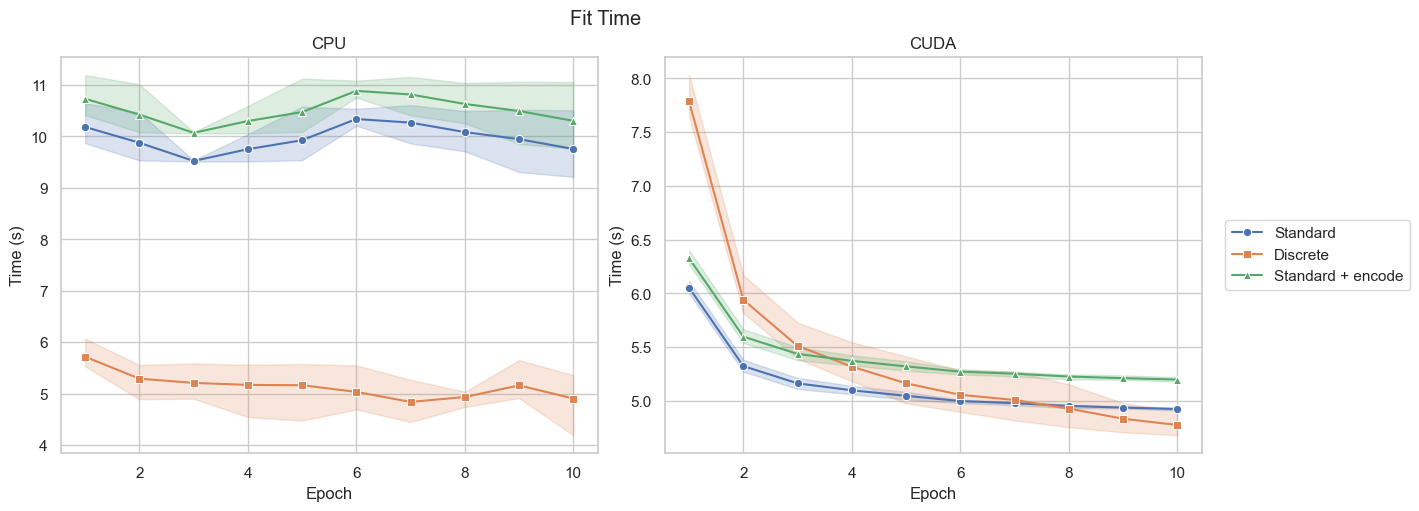

In [8]:
fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(12, 5), layout="compressed")

sns.lineplot(data=df_cpu_standard, x="epoch", y="fit/time", ax=ax0, label="Standard", marker="o")
sns.lineplot(data=df_cpu_discrete, x="epoch", y="fit/time", ax=ax0, label="Discrete", marker="s")
sns.lineplot(data=df_cpu_standard, x="epoch", y="fit/time_with_encode", ax=ax0, label="Standard + encode", marker="^")
ax0.set_title("CPU")
ax0.set_ylabel("Time (s)")
ax0.set_xlabel("Epoch")
ax0.get_legend().remove()

sns.lineplot(data=df_cuda_standard, x="epoch", y="fit/time", ax=ax1, label="Standard", marker="o")
sns.lineplot(data=df_cuda_discrete, x="epoch", y="fit/time", ax=ax1, label="Discrete", marker="s")
sns.lineplot(data=df_cuda_standard, x="epoch", y="fit/time_with_encode", ax=ax1, label="Standard + encode", marker="^")
ax1.set_title("CUDA")
ax1.set_ylabel("Time (s)")
ax1.set_xlabel("Epoch")
ax1.get_legend().remove()

handles, labels = ax0.get_legend_handles_labels()
fig.legend(handles, labels, bbox_to_anchor=(1.01, 0.5), loc="center left")
fig.suptitle("Fit Time")

## Inference Time

Text(0.5, 0.98, 'Inference Time (Test)')

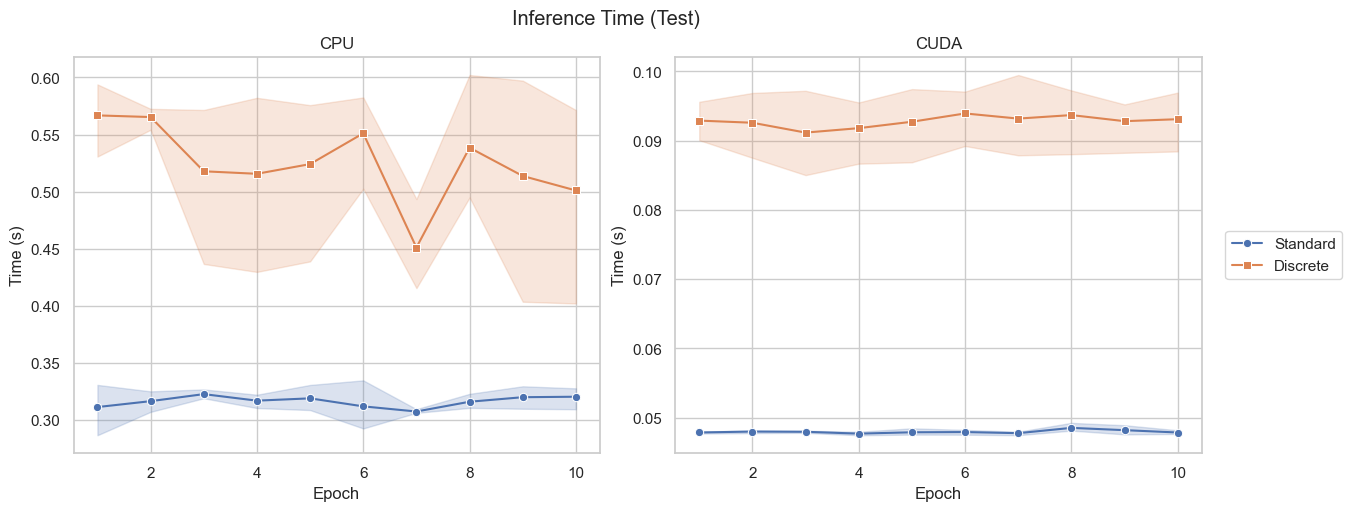

In [5]:
fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(12, 5), layout="compressed")

sns.lineplot(data=df_cpu_standard, x="epoch", y="predict_test/time", ax=ax0, label="Standard", marker="o")
sns.lineplot(data=df_cpu_discrete, x="epoch", y="predict_test/time", ax=ax0, label="Discrete", marker="s")
ax0.set_title("CPU")
ax0.set_ylabel("Time (s)")
ax0.set_xlabel("Epoch")
ax0.get_legend().remove()

sns.lineplot(data=df_cuda_standard, x="epoch", y="predict_test/time", ax=ax1, label="Standard", marker="o")
sns.lineplot(data=df_cuda_discrete, x="epoch", y="predict_test/time", ax=ax1, label="Discrete", marker="s")
ax1.set_title("CUDA")
ax1.set_ylabel("Time (s)")
ax1.set_xlabel("Epoch")
ax1.get_legend().remove()

handles, labels = ax0.get_legend_handles_labels()
fig.legend(handles, labels, bbox_to_anchor=(1.01, 0.5), loc="center left")
fig.suptitle("Inference Time (Test)")

## RAM Peak (Fit)

Text(0.5, 0.98, 'RAM Peak (Fit)')

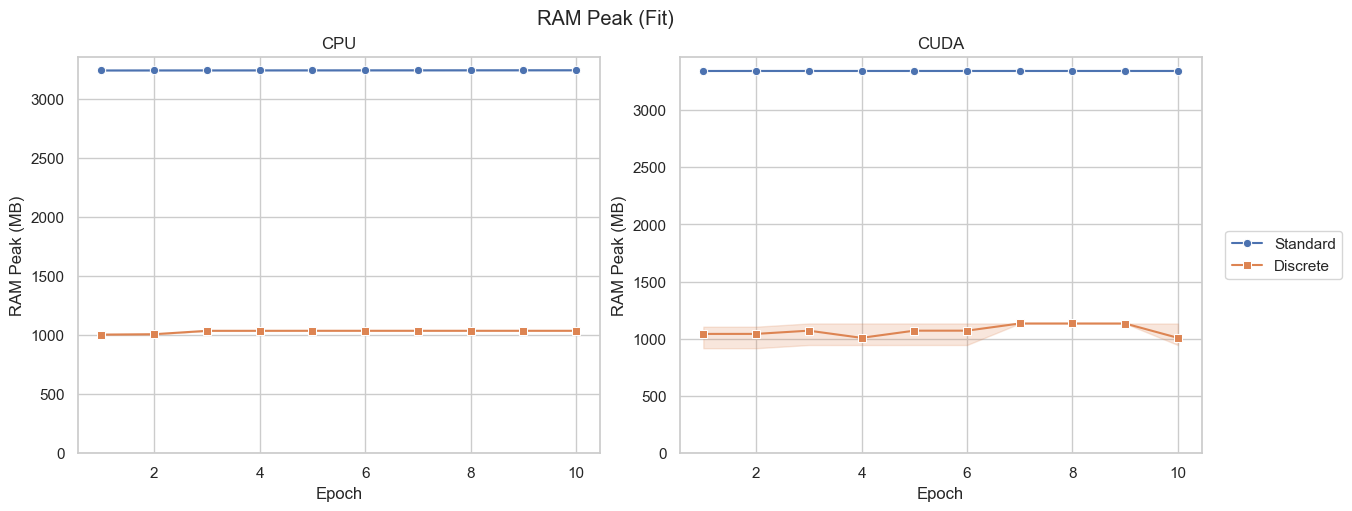

In [6]:
fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(12, 5), layout="compressed")

df_cpu_standard["fit/ram_peak_mb"] = df_cpu_standard["fit/ram_peak"] / 1e6
df_cpu_discrete["fit/ram_peak_mb"] = df_cpu_discrete["fit/ram_peak"] / 1e6
df_cuda_standard["fit/ram_peak_mb"] = df_cuda_standard["fit/ram_peak"] / 1e6
df_cuda_discrete["fit/ram_peak_mb"] = df_cuda_discrete["fit/ram_peak"] / 1e6

sns.lineplot(data=df_cpu_standard, x="epoch", y="fit/ram_peak_mb", ax=ax0, label="Standard", marker="o")
sns.lineplot(data=df_cpu_discrete, x="epoch", y="fit/ram_peak_mb", ax=ax0, label="Discrete", marker="s")
ax0.set_title("CPU")
ax0.set_ylabel("RAM Peak (MB)")
ax0.set_xlabel("Epoch")
ax0.set_ylim(bottom=0)
ax0.get_legend().remove()

sns.lineplot(data=df_cuda_standard, x="epoch", y="fit/ram_peak_mb", ax=ax1, label="Standard", marker="o")
sns.lineplot(data=df_cuda_discrete, x="epoch", y="fit/ram_peak_mb", ax=ax1, label="Discrete", marker="s")
ax1.set_title("CUDA")
ax1.set_ylabel("RAM Peak (MB)")
ax1.set_xlabel("Epoch")
ax1.set_ylim(bottom=0)
ax1.get_legend().remove()

handles, labels = ax0.get_legend_handles_labels()
fig.legend(handles, labels, bbox_to_anchor=(1.01, 0.5), loc="center left")
fig.suptitle("RAM Peak (Fit)")

## VRAM Peak (Fit) — CUDA only

Text(0.5, 0.98, 'VRAM Peak (Fit) — CUDA')

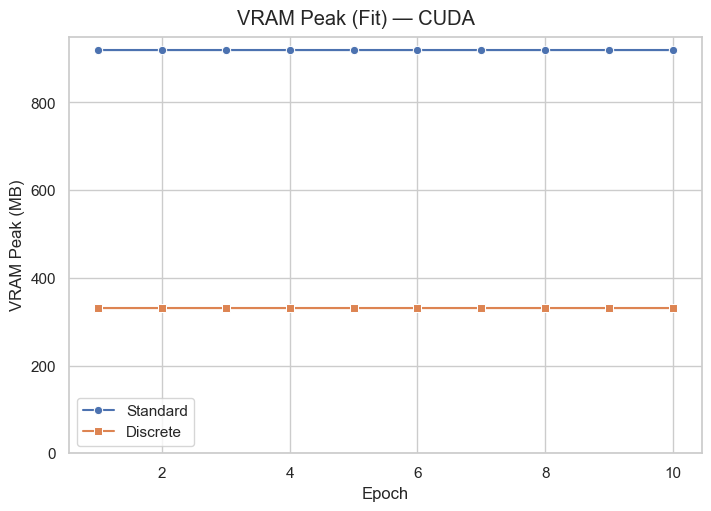

In [9]:
fig, ax = plt.subplots(figsize=(7, 5), layout="compressed")

df_cuda_standard["fit/vram_peak_mb"] = df_cuda_standard["fit/vram_peak"] / 1e6
df_cuda_discrete["fit/vram_peak_mb"] = df_cuda_discrete["fit/vram_peak"] / 1e6

sns.lineplot(data=df_cuda_standard, x="epoch", y="fit/vram_peak_mb", ax=ax, label="Standard", marker="o")
sns.lineplot(data=df_cuda_discrete, x="epoch", y="fit/vram_peak_mb", ax=ax, label="Discrete", marker="s")
ax.set_ylabel("VRAM Peak (MB)")
ax.set_xlabel("Epoch")
ax.set_ylim(bottom=0)
ax.legend()

fig.suptitle("VRAM Peak (Fit) — CUDA")